In [1]:
import pandas as pd

# Load datasets
fake = pd.read_csv("Fake.csv")
true = pd.read_csv("True.csv")

# Add labels
fake["label"] = 0
true["label"] = 1

# Combine datasets
data = pd.concat([fake, true])

# Shuffle dataset
data = data.sample(frac=1)

# Show first rows
print(data.head())

                                                   title  \
20519  Funerals crowd cemetery of dead from massive M...   
10761  AWESOME! SECRETARY OF STATE Rex Tillerson at R...   
20588  THE TRUTH ABOUT Phony Global Warming: Why Our ...   
12150  WOW! FORMER AMBASSADOR TO RUSSIA Lists Failure...   
10040  Factbox: Fed and presidential campaign: where ...   

                                                    text       subject  \
20519  JUCHITAN, Mexico (Reuters) - Anguished mourner...     worldnews   
10761  Secretary of State Rex Tillerson was a partici...      politics   
20588   No challenge  poses a greater threat to futur...     left-news   
12150                                                         politics   
10040  (Reuters) - Three of the five candidates runni...  politicsNews   

                     date  label  
20519  September 9, 2017       1  
10761        May 28, 2017      0  
20588        May 12, 2016      0  
12150        Dec 13, 2016      0  
10040      April 7,

In [2]:
# Keep only text and labels
data = data[["text", "label"]]

# Remove empty rows
data = data.dropna()

# Show dataset info
print(data.head())

print("\nDataset Shape:")
print(data.shape)

                                                    text  label
20519  JUCHITAN, Mexico (Reuters) - Anguished mourner...      1
10761  Secretary of State Rex Tillerson was a partici...      0
20588   No challenge  poses a greater threat to futur...      0
12150                                                         0
10040  (Reuters) - Three of the five candidates runni...      1

Dataset Shape:
(44898, 2)


In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

# Input (news text)
x = data["text"]

# Output (fake or real)
y = data["label"]

# Convert text into TF-IDF features
vectorizer = TfidfVectorizer(stop_words="english", max_df=0.7)

x_tfidf = vectorizer.fit_transform(x)

# Split dataset into training and testing
x_train, x_test, y_train, y_test = train_test_split(
    x_tfidf, y, test_size=0.2, random_state=42
)

print("TF-IDF completed successfully!")
print("Training data shape:", x_train.shape)
print("Testing data shape:", x_test.shape)

TF-IDF completed successfully!
Training data shape: (35918, 121689)
Testing data shape: (8980, 121689)


In [4]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# Create model
model = DecisionTreeClassifier()

# Train model
model.fit(x_train, y_train)

# Make predictions
y_pred = model.predict(x_test)

# Check accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

# Detailed performance report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Model Accuracy: 0.9956570155902005

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4694
           1       1.00      0.99      1.00      4286

    accuracy                           1.00      8980
   macro avg       1.00      1.00      1.00      8980
weighted avg       1.00      1.00      1.00      8980



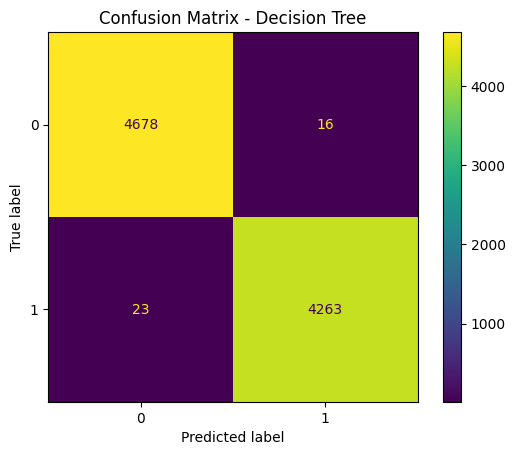

In [5]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()

plt.title("Confusion Matrix - Decision Tree")
plt.show()

In [6]:
from sklearn.linear_model import LogisticRegression

# Create Logistic Regression model
lr_model = LogisticRegression(max_iter=1000)

# Train model
lr_model.fit(x_train, y_train)

# Predictions
lr_pred = lr_model.predict(x_test)

# Accuracy
lr_accuracy = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", lr_accuracy)

print("\nClassification Report:\n")
print(classification_report(y_test, lr_pred))

Logistic Regression Accuracy: 0.9864142538975501

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.98      0.99      4694
           1       0.98      0.99      0.99      4286

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



In [7]:
from sklearn.ensemble import RandomForestClassifier

# Create Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train model
rf_model.fit(x_train, y_train)

# Make predictions
rf_pred = rf_model.predict(x_test)

# Accuracy
rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

print("\nClassification Report:\n")
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.9871937639198218

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4694
           1       0.98      0.99      0.99      4286

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



In [8]:
from sklearn.naive_bayes import MultinomialNB

# Create model
nb_model = MultinomialNB()

# Train model
nb_model.fit(x_train, y_train)

# Predictions
nb_pred = nb_model.predict(x_test)

# Accuracy
nb_accuracy = accuracy_score(y_test, nb_pred)

print("Naive Bayes Accuracy:", nb_accuracy)

print("\nClassification Report:\n")
print(classification_report(y_test, nb_pred))

Naive Bayes Accuracy: 0.9320712694877505

Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.94      0.94      4694
           1       0.93      0.92      0.93      4286

    accuracy                           0.93      8980
   macro avg       0.93      0.93      0.93      8980
weighted avg       0.93      0.93      0.93      8980



In [9]:
import pandas as pd

# Create comparison table
results = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Logistic Regression",
        "Random Forest",
        "Naive Bayes"
    ],
    
    "Accuracy": [
        accuracy,
        lr_accuracy,
        rf_accuracy,
        nb_accuracy
    ]
})

# Show results
print(results)

                 Model  Accuracy
0        Decision Tree  0.995657
1  Logistic Regression  0.986414
2        Random Forest  0.987194
3          Naive Bayes  0.932071


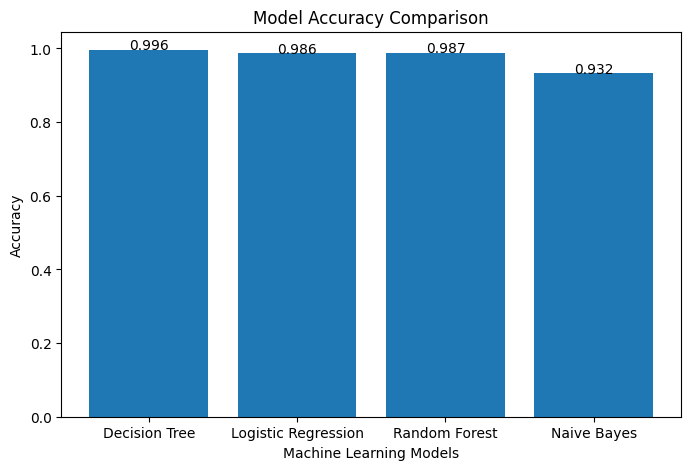

In [10]:
import matplotlib.pyplot as plt

# Create bar chart
plt.figure(figsize=(8,5))

plt.bar(results["Model"], results["Accuracy"])

# Labels and title
plt.xlabel("Machine Learning Models")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")

# Show values on top of bars
for i, value in enumerate(results["Accuracy"]):
    plt.text(i, value + 0.001, f"{value:.3f}", ha='center')

# Show graph
plt.show()